In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1. Data Loading & Inspection**

Load dataset

In [2]:
df = pd.read_excel("/content/online_course_recommendation.xlsx")

In [3]:
df.head()

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


In [4]:
df.shape

(100000, 14)

**2. Data Inspection**

Checking Missing Values and Duplicates

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  object 
 3   instructor                100000 non-null  object 
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  object 
 6   difficulty_level          100000 non-null  object 
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  object 
 12  time_spent_hours          100000 non-null  float64
 13  previous_courses_taken    100000 non-null  in

In [6]:
df.isnull().sum()

,0
user_id,0
course_id,0
course_name,0
instructor,0
course_duration_hours,0
certification_offered,0
difficulty_level,0
rating,0
enrollment_numbers,0
course_price,0


In [7]:
df.duplicated().sum()

0

**3. Outlier Analysis**

Before Outlier Capping

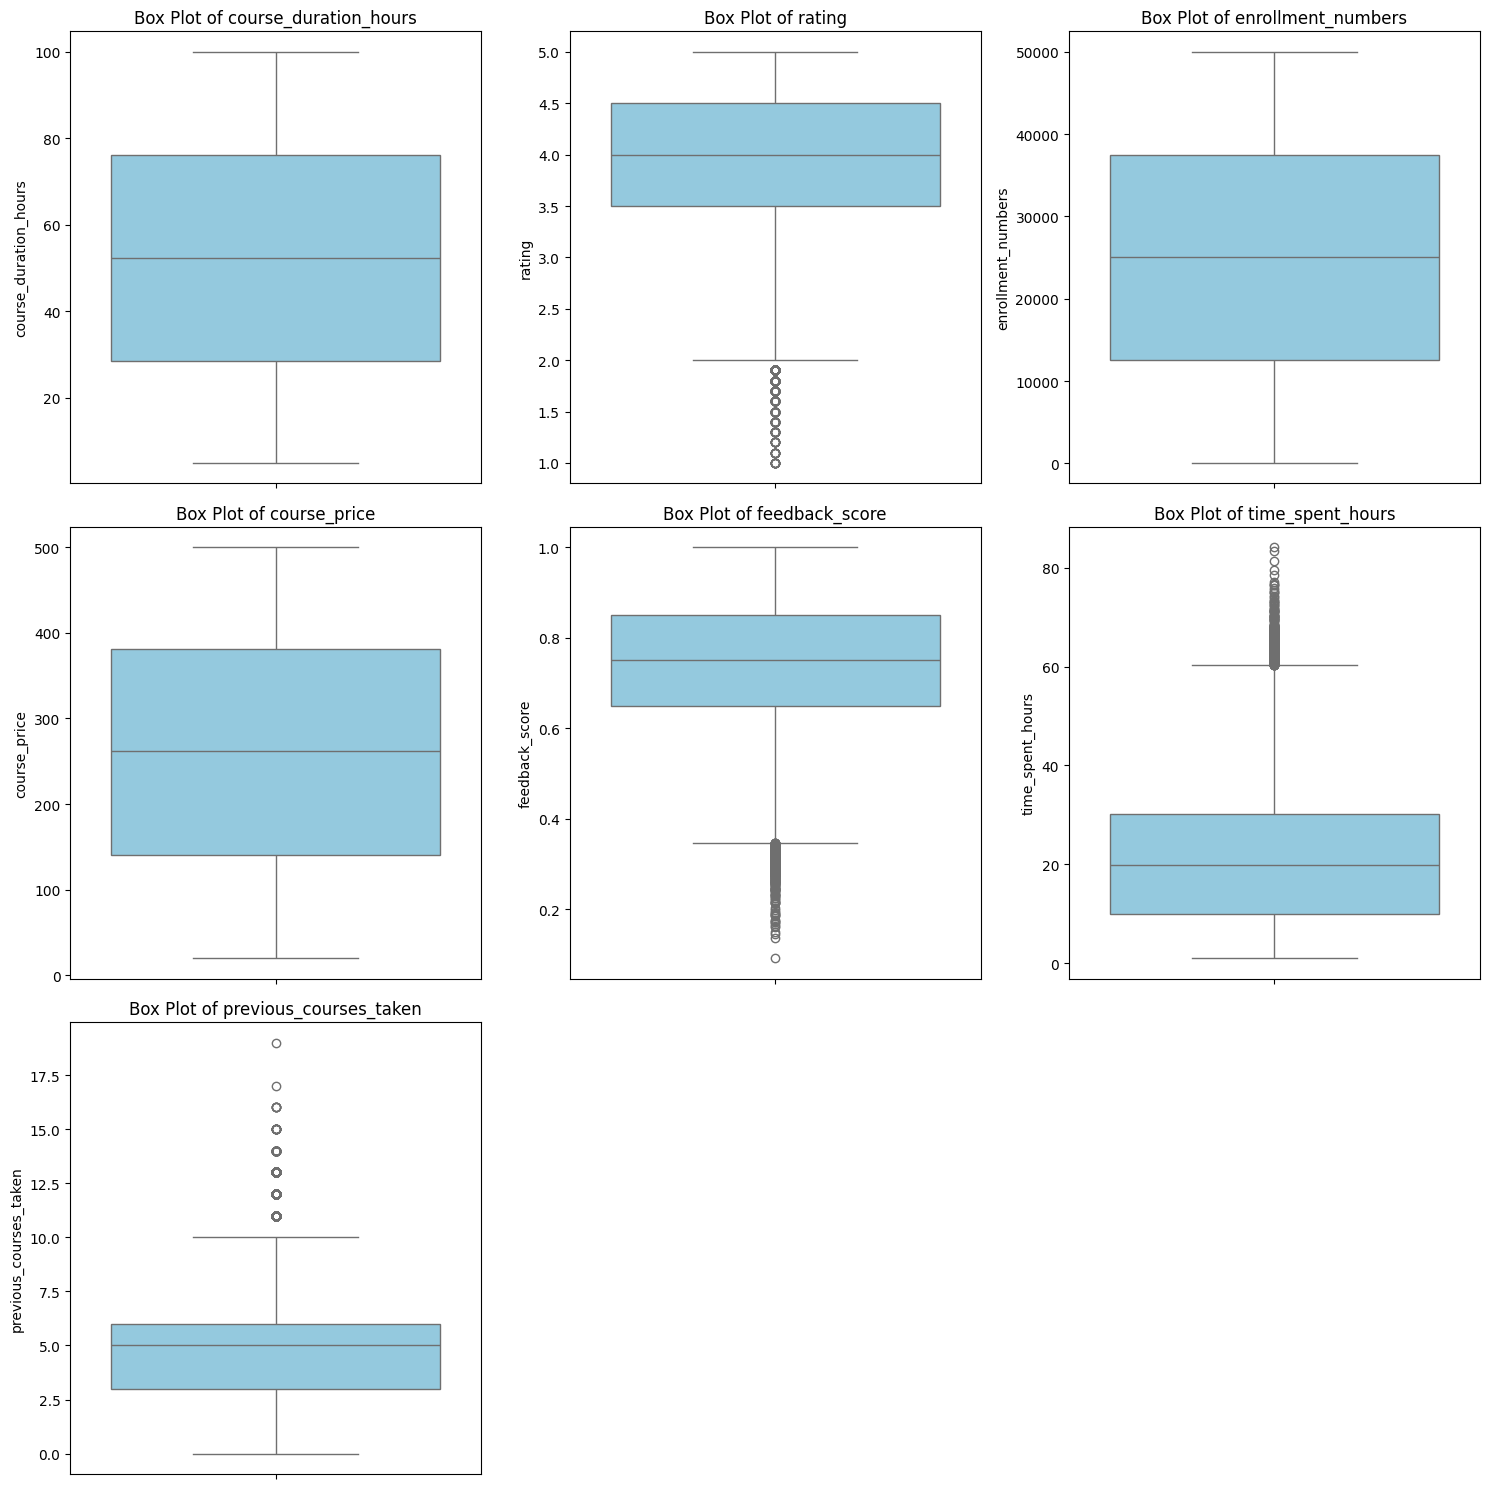

In [8]:

numeric_cols = df.select_dtypes(include=['int64','float64']).columns.drop(['user_id', 'course_id'], errors='ignore')

# Calculate grid dimensions
num_cols = len(numeric_cols)
n_cols = 3                          # number of subplots per row
n_rows = (num_cols + n_cols - 1) // n_cols  # ceiling division

plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()


After Outlier Capping

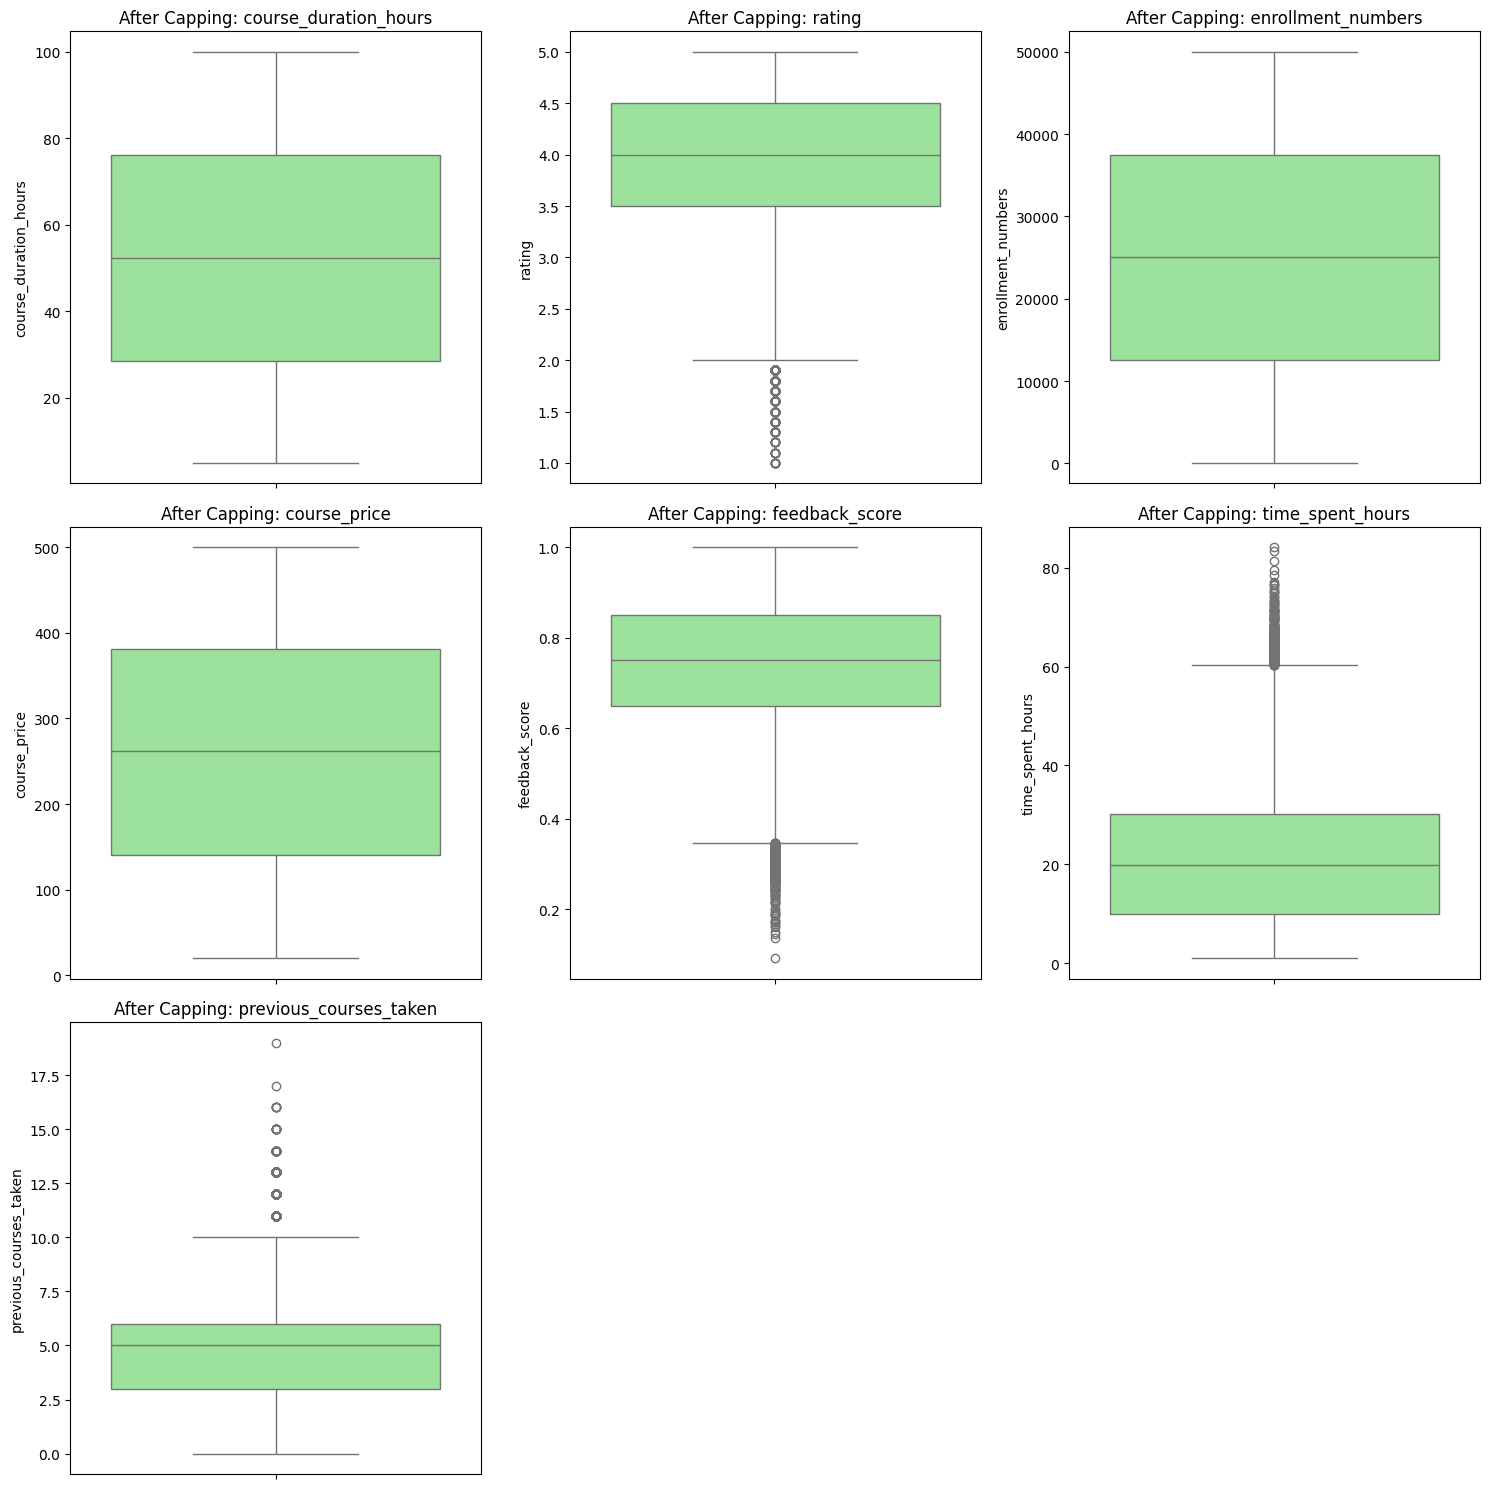

In [9]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.drop(['user_id','course_id'], errors='ignore')

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'After Capping: {col}')
plt.tight_layout()
plt.show()


**4. Histogram Visualization**

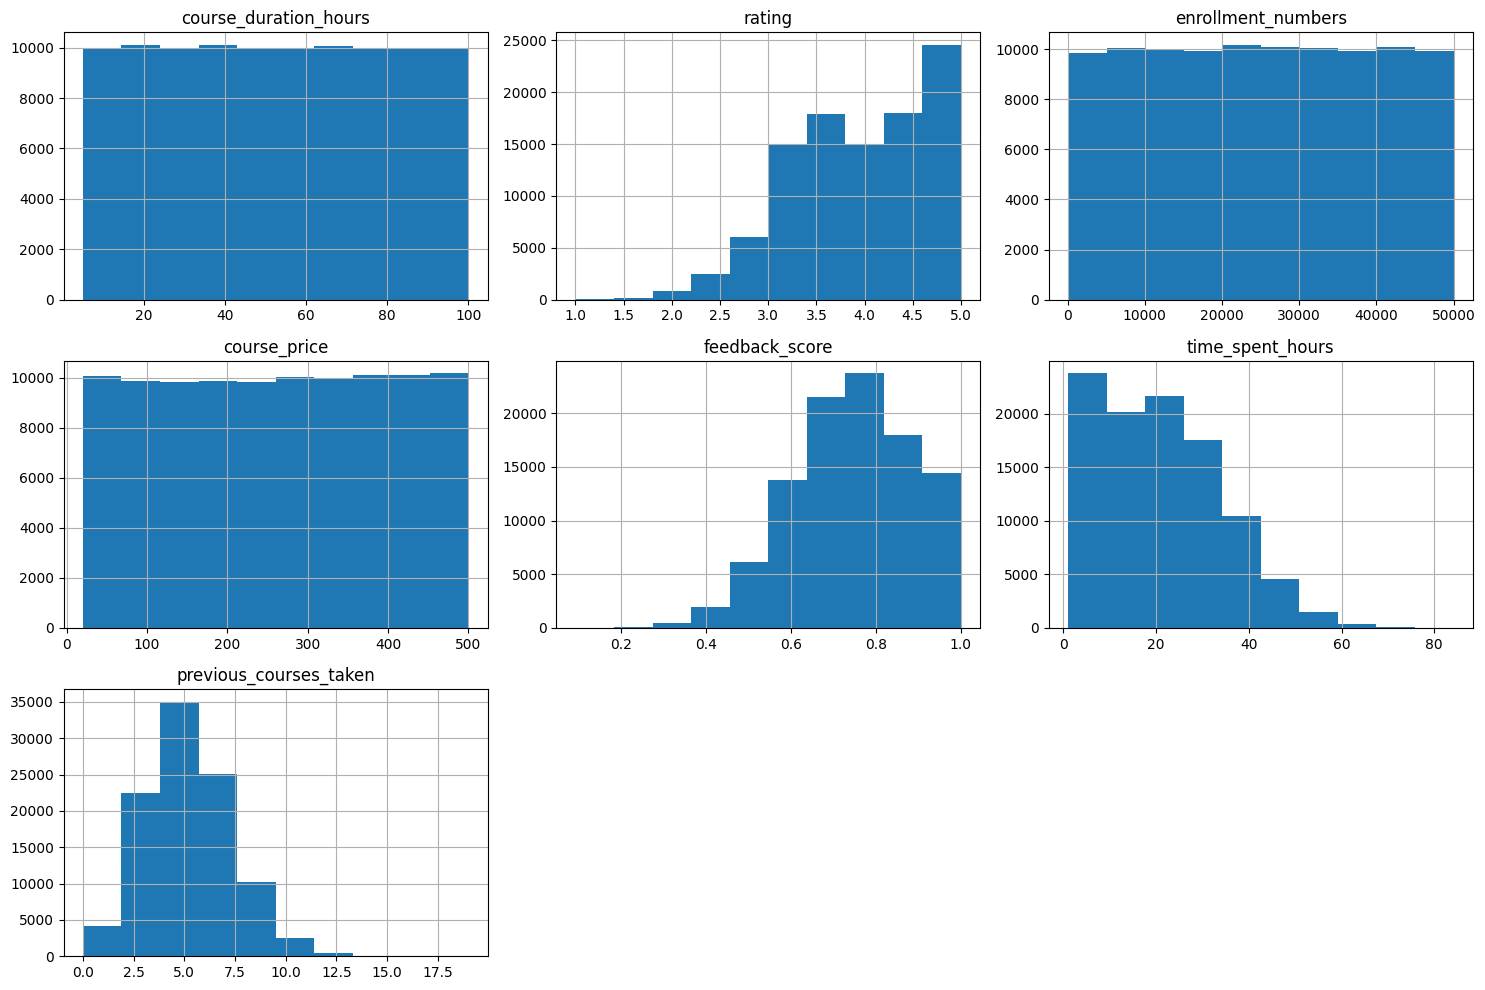

In [10]:
df.drop(columns=['user_id','course_id'], errors='ignore').hist(figsize=(15,10))
plt.tight_layout()
plt.show()


**5. Category Visualizations**

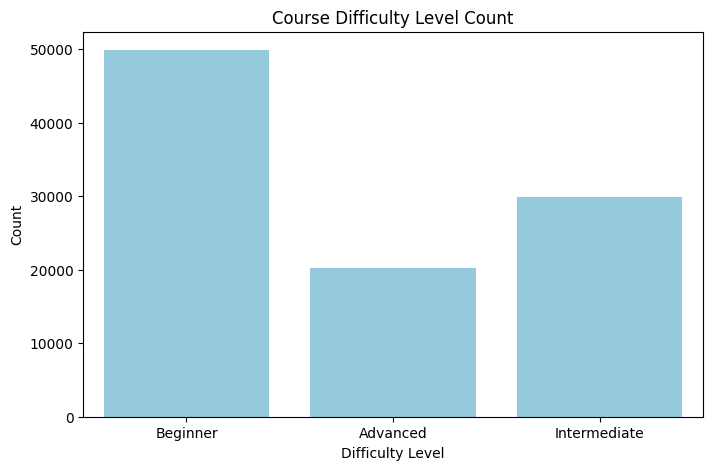

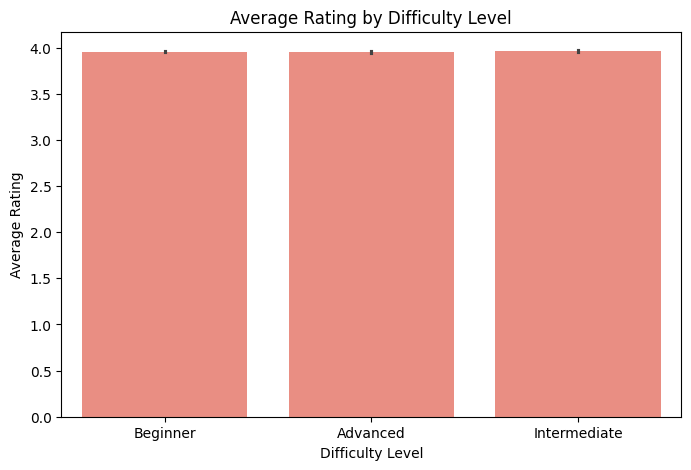

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='difficulty_level', data=df, color='skyblue')
plt.title('Course Difficulty Level Count')
plt.xlabel('Difficulty Level')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x='difficulty_level', y='rating', data=df, estimator='mean', color='salmon')
plt.title('Average Rating by Difficulty Level')
plt.xlabel('Difficulty Level')
plt.ylabel('Average Rating')
plt.show()


**6. Correlation Analysis**

Correlation Heatmap for Numeric

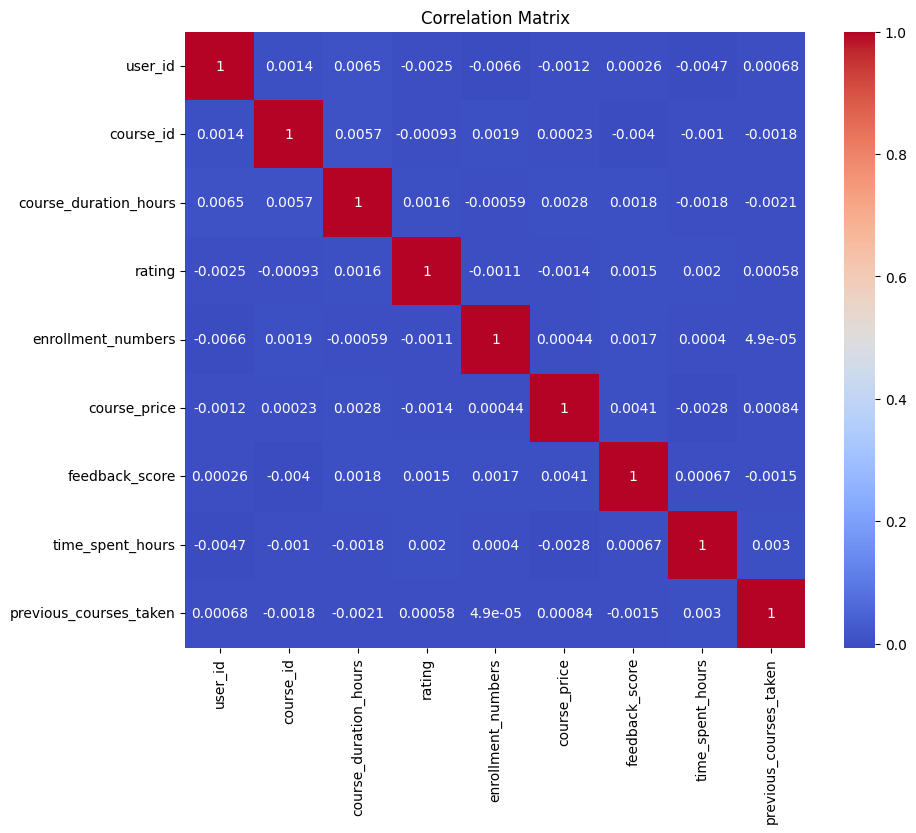

In [12]:
corr = df.select_dtypes(include=['int64','float64']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


**7. Feature Encoding & Preprocessing**

In [13]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

Encode Binary Features

In [14]:
# Define correct categories per feature
encoder_binary = OrdinalEncoder(categories=[['No','Yes'], ['No','Yes']])

df[['certification_offered','study_material_available']] = encoder_binary.fit_transform(
    df[['certification_offered','study_material_available']]
).astype(int)


* An OrdinalEncoder named encoder_binary is created with explicit categories [ ['No','Yes'], ['No','Yes'] ], applying the same 0/1 mapping to both features.
* The two columns certification_offered and study_material_available are transformed using fit_transform, converting 'No' to 0 and 'Yes' to 1.
* The resulting 0/1 values replace the original columns in df, then .astype(int) ensures integer dtype.
* This provides a consistent binary encoding for both features and makes downstream modeling straightforward.

Encode Difficulty Level Ordinally

In [15]:
# Encode difficulty level ordinally
difficulty_categories = ['Beginner','Intermediate','Advanced']
encoder_diff = OrdinalEncoder(categories=[difficulty_categories])

df['difficulty_level_encoded'] = encoder_diff.fit_transform(
    df[['difficulty_level']]
).astype(int)

* An OrdinalEncoder named encoder_diff is created with a single category list: ['Beginner','Intermediate','Advanced'], establishing a 0→Beginner, 1→Intermediate, 2→Advanced mapping.
* The difficulty_level column is transformed with fit_transform, converting its textual levels to numeric codes according to the defined order.
* The encoded values are stored in a new column difficulty_level_encoded in df, with .astype(int) ensuring integer type.
* This preserves the ordinal relationship (low to high) for use in models that can leverage order information.

**8. Recommendation Model — Collaborative Filtering**

Collaborative Filtering

install this libraries before running the the below code

* import sys

* !{sys.executable} -m pip uninstall -y numpy

* !{sys.executable} -m pip install 'numpy<2'

* !{sys.executable} -m pip uninstall -y scikit-surprise

* !{sys.executable} -m pip install scikit-surprise


In [16]:
# Pick a random user from the dataset
if 'user_id' in df.columns:
    sample_user = df['user_id'].sample(1).iloc[0]
    print("Sample User ID:", sample_user)
else:
    raise ValueError("Column 'user_id' not found in df")


Sample User ID: 6619


SVD Model

In [17]:


from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

# Prepare data for Surprise
reader = Reader(rating_scale=(df['rating'].min(), df['rating'].max()))
data = Dataset.load_from_df(df[['user_id','course_id','rating']], reader)

# Train/test split
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train SVD model
svd_algo = SVD(n_factors=50, random_state=42)
svd_algo.fit(trainset)

# Evaluate on testset
predictions = svd_algo.test(testset)
print("SVD RMSE:", accuracy.rmse(predictions))
print("SVD MAE:", accuracy.mae(predictions))


RMSE: 0.7423
SVD RMSE: 0.7423169288206619
MAE:  0.6095
SVD MAE: 0.6095318965054712


Item-Based CF

In [18]:
from surprise import KNNWithMeans

# Build full trainset for item-based model
full_trainset = data.build_full_trainset()

sim_options = {
    "name": "cosine",
    "user_based": False  # Item-based CF
}

item_cf_algo = KNNWithMeans(sim_options=sim_options)
item_cf_algo.fit(full_trainset)


Computing the cosine similarity matrix...
Done computing similarity matrix.


In [19]:
def recommend_knn_item(user_id, top_n=10):
    try:
        inner_uid = item_cf_algo.trainset.to_inner_uid(user_id)
    except ValueError:
        return []

    user_rated_inner = [iid for (iid, _) in item_cf_algo.trainset.ur[inner_uid]]

    predictions = []
    for inner_iid in item_cf_algo.trainset.all_items():
        if inner_iid in user_rated_inner:
            continue
        raw_iid = item_cf_algo.trainset.to_raw_iid(inner_iid)
        est = item_cf_algo.predict(user_id, raw_iid).est
        predictions.append((raw_iid, est))

    predictions.sort(key=lambda x: x[1], reverse=True)
    return [cid for cid,_ in predictions[:top_n]]

print("Item-Based CF (KNN) Recs:", recommend_knn_item(sample_user, 10))


Item-Based CF (KNN) Recs: [6588, 3627, 3087, 9232, 8754, 6608, 4275, 9174, 2417, 4424]


**9️. Content-Based Filtering**

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

# 1) Pick only text columns that actually exist
text_columns = ['course_name', 'course_title', 'difficulty_level']
available_text_cols = [col for col in text_columns if col in df.columns]
print("Using text columns:", available_text_cols)

# 2) Combine text into a 'content' column
df['content'] = df[available_text_cols].agg(
    lambda x: ' '.join(x.dropna().astype(str)), axis=1
)

# 3) Fit the TF‑IDF vectorizer once
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['content'])

# 4) Map course_id → row position
#    Use pandas Series for mapping course_id to positional index
course_ids = df['course_id'].tolist()
course_idx_map = {cid: idx for idx, cid in enumerate(course_ids)}

def recommend_content_based(course_id, top_n=10):
    """
    Return top_n similar course_ids using TF‑IDF + cosine similarity.
    """
    # Safe membership test
    if course_id not in course_idx_map:
        return []

    # Use positional index from mapping (no pandas Series here)
    idx = course_idx_map[course_id]

    # Compute cosine similarity for just this course
    target_vec = tfidf_matrix[idx]
    sim_scores = linear_kernel(target_vec, tfidf_matrix).flatten()

    # Sort indices by similarity descending
    sorted_indices = sim_scores.argsort()[::-1]

    # Exclude itself
    sorted_indices = [i for i in sorted_indices if i != idx]

    # Pick top_n similar items
    top_indices = sorted_indices[:top_n]

    # Return corresponding course_ids
    return [course_ids[i] for i in top_indices]


Using text columns: ['course_name', 'difficulty_level']


**10️. Hybrid Recommendation Function**

In [21]:
def hybrid_recommend(user_id, top_n=10, alpha=0.6, beta=0.4):
    # SVD predictions
    preds = []
    for c in df['course_id'].unique():
        if ((df['user_id']==user_id) & (df['course_id']==c)).any():
            continue
        est = svd_algo.predict(user_id, c).est   # <-- fixed here
        preds.append((c, est))
    preds = sorted(preds, key=lambda x: x[1], reverse=True)
    svd_top = [c for c,_ in preds[:top_n]]

    # Item-CF
    item_top = recommend_knn_item(user_id, top_n)   # <-- also fix function name if needed

    # Content
    content_top = []
    for c in svd_top:
        content_top.extend(recommend_content_based(c, top_n=3))

    combined = list(set(svd_top + item_top + content_top))
    return combined[:top_n]


**11.Testing  models**

In [23]:


# 1. Define a sample user
sample_user = df['user_id'].sample(1).iloc[0]
print("Evaluating for User:", sample_user)

# 2. Test SVD Recommendations (top 10 by predicted score)
svd_recs = sorted(
    [(cid, svd_algo.predict(sample_user, cid).est)
     for cid in df['course_id'].unique()
     if not ((df['user_id']==sample_user) & (df['course_id']==cid)).any()],
    key=lambda x: x[1], reverse=True
)[:10]
svd_recs_ids = [cid for cid,_ in svd_recs]
print("SVD Recs:", svd_recs_ids)

# 3. Item‑CF Recommendations
itemcf_recs = recommend_knn_item(sample_user, top_n=10)
print("Item‑CF Recs:", itemcf_recs)

# 4. Content‑Based Recommendations
# Make sure to pick a *single* course_id
if not df['course_id'].empty:
    example_course_id = df['course_id'].iloc[0]  # single scalar
    content_recs = recommend_content_based(example_course_id, top_n=10)
    print(f"Content‑CF Recs for course {example_course_id}:", content_recs)
else:
    content_recs = []
    print("No course_id found for Content‑CF test")

# 5. Hybrid Recommendations
hybrid_recs = hybrid_recommend(sample_user, top_n=10)
print("Hybrid Recs:", hybrid_recs)


Evaluating for User: 1525
SVD Recs: [3045, 1871, 7814, 4857, 8415, 9964, 8326, 364, 6289, 9531]
Item‑CF Recs: [6973, 1279, 4424, 9945, 2471, 1668, 9783, 7611, 6545, 7736]
Content‑CF Recs for course 9366: [3694, 4024, 5866, 5604, 5551, 4283, 8139, 8179, 993, 7001]
Hybrid Recs: [1668, 7814, 8326, 1159, 7303, 2566, 3469, 6289, 6545, 5908]


Recommendation Display (with Course Names)

In [24]:


def show_recommendations(user_id, top_n=10):
    #  1. SVD Recommendations
    svd_recs = sorted(
        [(cid, svd_algo.predict(user_id, cid).est)
         for cid in df['course_id'].unique()
         if not ((df['user_id']==user_id) & (df['course_id']==cid)).any()],
        key=lambda x: x[1], reverse=True
    )[:top_n]
    svd_recs_names = df[df['course_id'].isin([cid for cid,_ in svd_recs])]['course_name'].tolist()

    # 2. Item-CF Recommendations
    itemcf_recs_ids = recommend_knn_item(user_id, top_n)
    itemcf_recs_names = df[df['course_id'].isin(itemcf_recs_ids)]['course_name'].tolist()

    #3. Content-CF Recommendations
    if svd_recs:
        # Use the first SVD recommended course as reference
        content_recs_ids = recommend_content_based(svd_recs[0][0], top_n)
        content_recs_names = df[df['course_id'].isin(content_recs_ids)]['course_name'].tolist()
    else:
        content_recs_names = []

    #4. Hybrid Recommendations
    hybrid_recs_ids = hybrid_recommend(user_id, top_n)
    hybrid_recs_names = df[df['course_id'].isin(hybrid_recs_ids)]['course_name'].tolist()

    # Print All Recommendations
    print(f"Recommendations for User ID: {user_id}\n")
    print(" SVD Recommendations:")
    print(svd_recs_names)
    print("\n Item-CF Recommendations:")
    print(itemcf_recs_names)
    print("\n Content-CF Recommendations (based on first SVD course):")
    print(content_recs_names)
    print("\n Hybrid Recommendations:")
    print(hybrid_recs_names)


# Example usage:
sample_user = df['user_id'].sample(1).iloc[0]
show_recommendations(sample_user, top_n=10)


Recommendations for User ID: 27589

🔹 SVD Recommendations:
['DevOps and Continuous Deployment', 'Networking and System Administration', 'Graphic Design with Canva', 'Personal Finance and Wealth Building', 'Project Management Fundamentals', 'Python for Beginners', 'Cybersecurity for Professionals', 'Ethical Hacking Masterclass', 'Mobile App Development with Swift', 'Python for Beginners', 'Ethical Hacking Masterclass', 'Networking and System Administration', 'Graphic Design with Canva', 'Fitness and Nutrition Coaching', 'Game Development with Unity', 'Mobile App Development with Swift', 'Stock Market and Trading Strategies', 'Fitness and Nutrition Coaching', 'Project Management Fundamentals', 'Networking and System Administration', 'Networking and System Administration', 'Data Visualization with Tableau', 'Cloud Computing Essentials', 'AI for Business Leaders', 'Stock Market and Trading Strategies', 'Photography and Video Editing', 'Data Visualization with Tableau', 'Advanced Machine Le

Recommendation Display with Scores

In [25]:


def show_recommendations_with_scores(user_id, top_n=10):
    # 1. SVD Recommendations
    svd_recs = sorted(
        [(cid, svd_algo.predict(user_id, cid).est)
         for cid in df['course_id'].unique()
         if not ((df['user_id']==user_id) & (df['course_id']==cid)).any()],
        key=lambda x: x[1], reverse=True
    )[:top_n]
    svd_recs_info = [(df[df['course_id']==cid]['course_name'].values[0], round(score, 2))
                     for cid, score in svd_recs]

    #  2. Item-CF Recommendations
    itemcf_recs_ids = recommend_knn_item(user_id, top_n)
    itemcf_recs_info = [(df[df['course_id']==cid]['course_name'].values[0],
                         round(item_cf_algo.predict(user_id, cid).est, 2))
                        for cid in itemcf_recs_ids]

    #  3. Content-CF Recommendations
    content_recs_info = []
    if svd_recs:
        reference_cid = svd_recs[0][0]  # first SVD recommended course
        content_recs_ids = recommend_content_based(reference_cid, top_n)
        idx_map = {cid: idx for idx, cid in enumerate(df['course_id'])}
        target_idx = idx_map[reference_cid]
        target_vec = tfidf_matrix[target_idx]
        sim_scores = linear_kernel(target_vec, tfidf_matrix).flatten()
        content_recs_info = [(df[df['course_id']==cid]['course_name'].values[0],
                              round(sim_scores[idx_map[cid]], 3))
                             for cid in content_recs_ids]

    # 4. Hybrid Recommendations
    hybrid_recs_ids = hybrid_recommend(user_id, top_n)
    hybrid_recs_names = [df[df['course_id']==cid]['course_name'].values[0] for cid in hybrid_recs_ids]

    #  Print All Recommendations
    print(f"Recommendations for User ID: {user_id}\n")

    print("🔹 SVD Recommendations (Predicted Rating):")
    for name, score in svd_recs_info:
        print(f"{name} — {score}")

    print("\n🔹 Item-CF Recommendations (Estimated Rating):")
    for name, score in itemcf_recs_info:
        print(f"{name} — {score}")

    print("\n🔹 Content-CF Recommendations (Similarity Score):")
    for name, score in content_recs_info:
        print(f"{name} — {score}")

    print("\n🔹 Hybrid Recommendations:")
    for name in hybrid_recs_names:
        print(name)

# Example usage:
sample_user = df['user_id'].sample(1).iloc[0]
show_recommendations_with_scores(sample_user, top_n=10)


Recommendations for User ID: 39551

🔹 SVD Recommendations (Predicted Rating):
Personal Finance and Wealth Building — 4.52
Networking and System Administration — 4.51
Graphic Design with Canva — 4.5
Graphic Design with Canva — 4.41
Stock Market and Trading Strategies — 4.39
Fundamentals of Digital Marketing — 4.39
Photography and Video Editing — 4.39
Ethical Hacking Masterclass — 4.39
Mobile App Development with Swift — 4.37
Project Management Fundamentals — 4.37

🔹 Item-CF Recommendations (Estimated Rating):
Data Visualization with Tableau — 5.0
Ethical Hacking Masterclass — 5.0
Game Development with Unity — 5.0
Advanced Machine Learning — 4.99
Game Development with Unity — 4.94
Cybersecurity for Professionals — 4.89
Fitness and Nutrition Coaching — 4.83
Data Visualization with Tableau — 4.8
Data Visualization with Tableau — 4.8
Stock Market and Trading Strategies — 4.73

🔹 Content-CF Recommendations (Similarity Score):
Cybersecurity for Professionals — 1.0
Graphic Design with Canva — 

**11. Save Trained Models**

In [26]:
import joblib

# Example: saving the best SVD model
joblib.dump(svd_algo, 'best_svd_model.pkl')

# Example: saving the best Hybrid (if you want to reuse functions + TF-IDF)
joblib.dump({
    'svd': svd_algo,
    'item_cf': item_cf_algo,
    'tfidf_matrix': tfidf_matrix,
    'course_idx_map': course_idx_map,
    'df': df
}, 'best_hybrid_model.pkl')


['best_hybrid_model.pkl']